In [1]:
import os
import numpy as np
import math
import pandas as pd
import seaborn as sns
import torch
os.environ["KERAS_BACKEND"] = "torch"
import keras
from keras.callbacks import Callback
from datamodules import data_processors
from sklearn.preprocessing import StandardScaler
import sys
print(sys.version)
from rusmodules import eigenvals, geometry
from rusmodules.inverse import get_constants

(null): No such file or directory
(null): No such file or directory
(null): No such file or directory
(null): No such file or directory


3.14.6 (main, Jun 10 2026, 10:03:53) [GCC 15.2.0]


In [2]:
import matplotlib
matplotlib.rcParams.update({
  #"text.usetex": True,
  "font.family": "serif",
  "font.serif": ["NewComputerModernMath"],
  "mathtext.fontset": "cm",
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "font.size": 11,
  "axes.labelsize": "x-large",
  "xtick.labelsize": 13,
  "ytick.labelsize": 13,
  "legend.fontsize": 13,
  "axes.linewidth": 0.8,
  "lines.linewidth": 1.2,
  "lines.markersize": 3.5,
})
import matplotlib.pyplot as plt
%matplotlib inline
#plt.style.use('ggplot')

In [3]:
n_pow = 20
def custom_activation(x):
    return (1/n_pow) * torch.log((1 + torch.exp(n_pow * x)) / (1 + torch.exp(n_pow * (x - 1))))
#fin función

# Wrap the function in a Keras custom layer
@keras.saving.register_keras_serializable()
class CustomActivationLayer(keras.layers.Layer):
    def __init__(self, **kwargs):
        super(CustomActivationLayer, self).__init__(**kwargs)
    
    def call(self, inputs):
        # Ensure inputs are Torch tensors
        inputs = torch.tensor(inputs) if not isinstance(inputs, torch.Tensor) else inputs
        return custom_activation(inputs)
    #fin función
#fin clase
path_to_current_model_cubic = "models/cubico_L4.keras"
modelo_cubico = keras.models.load_model(path_to_current_model_cubic)
path_to_current_model_isotropic = "models/isotropico_act_custom_6.keras"
modelo_isotropico = keras.models.load_model(path_to_current_model_isotropic)
stats_modelo_cubico = pd.read_csv(path_to_current_model_cubic[:-6]+"_stats.csv")
stats_modelo_cubico = stats_modelo_cubico.set_index("Unnamed: 0")
dic_stats = dict(map(lambda x: (x, dict(map(lambda y: (y, stats_modelo_cubico[y][x]),stats_modelo_cubico.keys()))), ["mean", "std"]))
modelo_datos = {"model": modelo_cubico, **dic_stats}

N_data = 200
Ng = 6
shape_def = "Parallelepiped"
N_eig_iso = 5
N_eig_cubic = 20
features_cubic = ["eta", "beta"] + list(map(lambda x: "x_" + str(x), range(N_eig_cubic + 1)))
features_iso = ["eta", "beta"] + list(map(lambda x: "eig_moño_" + str(x+1), range(N_eig_iso)))
np.random.seed(53)

In [4]:
#geometries = geometry.generate_sphere_surface_points_random(N_data, 0.61*np.pi, np.pi)
geo_df = pd.DataFrame()
geo_df["eta"] = (np.pi/2)*np.ones(N_data)
geo_df["beta"] = 0.82*np.pi*np.ones(N_data)
print(max(geo_df["eta"])/np.pi)
print(max(geo_df["beta"])/np.pi)

0.5
0.8199999999999998


In [5]:
geo_df

,eta,beta
0,1.570796,2.576106
1,1.570796,2.576106
2,1.570796,2.576106
3,1.570796,2.576106
4,1.570796,2.576106
...,...,...
195,1.570796,2.576106
196,1.570796,2.576106
197,1.570796,2.576106
198,1.570796,2.576106


In [6]:
M_max = 150 #GPa
datos_iso = pd.DataFrame()
datos_cubic = pd.DataFrame()
datos_iso["K"] = np.random.uniform(10, M_max, N_data)
datos_iso["G"] = np.random.uniform(10, M_max, N_data)
datos_cubic["K"] = np.random.uniform(10, 2*M_max, N_data)
datos_cubic["mu"] = np.random.uniform(10, M_max, N_data)
datos_cubic["a"] = np.random.uniform(10, (2/3)*M_max, N_data)
datos_cubic["C11"] = datos_cubic["K"] + 2*datos_cubic["a"]
datos_cubic["C12"] = datos_cubic["K"] - datos_cubic["a"]
datos_cubic["C44"] = datos_cubic["mu"]
datos_iso["phi_K"] = np.arctan(datos_iso["G"]/datos_iso["K"])
datos_cubic["phi_K"] = np.arctan(np.sqrt((datos_cubic["a"])**2 + (datos_cubic["mu"])**2)/datos_cubic["K"])
datos_cubic["phi_a"] = np.arctan(datos_cubic["mu"]/datos_cubic["a"])
datos_iso = pd.concat((datos_iso, geo_df), axis = 1)
datos_cubic = pd.concat((datos_cubic, geo_df), axis = 1)

In [7]:
datos_iso

,K,G,phi_K,eta,beta
0,128.532737,124.522981,0.769554,1.570796,2.576106
1,88.563176,132.073092,0.980102,1.570796,2.576106
2,73.682556,88.946675,0.878982,1.570796,2.576106
3,59.304488,108.130285,1.069141,1.570796,2.576106
4,92.019194,67.618142,0.633719,1.570796,2.576106
...,...,...,...,...,...
195,88.766926,55.583776,0.559445,1.570796,2.576106
196,42.942528,77.488009,1.064747,1.570796,2.576106
197,13.146474,55.712342,1.339065,1.570796,2.576106
198,64.618515,11.222698,0.171961,1.570796,2.576106


In [8]:
datos_cubic

,K,mu,a,C11,C12,C44,phi_K,phi_a,eta,beta
0,130.078002,81.308633,98.017628,326.113257,32.060374,81.308633,0.774810,0.692490,1.570796,2.576106
1,99.010440,70.370286,83.816722,266.643883,15.193718,70.370286,0.835392,0.698410,1.570796,2.576106
2,130.720916,64.787223,99.899202,330.519320,30.821714,64.787223,0.738782,0.575338,1.570796,2.576106
3,28.681227,72.994951,76.948114,182.577455,-48.266888,72.994951,1.306695,0.759040,1.570796,2.576106
4,254.261095,40.466621,65.301459,384.864013,188.959635,40.466621,0.293422,0.554771,1.570796,2.576106
...,...,...,...,...,...,...,...,...,...,...
195,45.090106,33.906572,48.804156,142.698418,-3.714050,33.906572,0.921716,0.607192,1.570796,2.576106
196,30.748169,118.598762,71.355432,173.459034,-40.607263,118.598762,1.352193,1.029161,1.570796,2.576106
197,250.666320,100.210629,89.841536,430.349392,160.824784,100.210629,0.492743,0.839903,1.570796,2.576106
198,110.971573,87.923693,56.145625,223.262823,54.825948,87.923693,0.754518,1.002497,1.570796,2.576106


In [9]:
datos_cubic["C11_pred"] = 0.0
datos_cubic["C12_pred"] = 0.0
datos_cubic["C44_pred"] = 0.0

datos_iso["K_pred"] = 0.0
datos_iso["G_pred"] = 0.0
for i in range(N_eig_iso):
  datos_iso[f"eig_{i}"] = 0.0
  datos_iso[f"eig_moño_{i}"] = 0.0

In [10]:
for i in datos_iso.index:
  Ki = datos_iso.at[i, "K"]
  Gi = datos_iso.at[i, "G"]
  eta_g = datos_iso.at[i, "eta"]
  beta_g = datos_iso.at[i, "beta"]
  C_iso = eigenvals.get_elastic_constants({"K": Ki, "mu": Gi})
  eigs_iso = eigenvals.get_eigenvalues(Ng, C_iso, eta_g, beta_g, shape_def)["eig"][:N_eig_iso + 1]
  for j in range(len(eigs_iso)):
    datos_iso.at[i, f"eig_{j}"] = eigs_iso[j]
    if j == 0:
      datos_iso.at[i, f"eig_moño_{j}"] = eigs_iso[j]
    elif j == 1:
      datos_iso.at[i, f"eig_moño_{j}"] = 1/eigs_iso[j]
    else:
      datos_iso.at[i, f"eig_moño_{j}"] = eigs_iso[j-1]/eigs_iso[j]

datos_iso["phi_K_pred"] = modelo_isotropico.predict(datos_iso[features_iso])*(np.pi/2)
  

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


In [11]:
datos_iso[["phi_K", "phi_K_pred", "K", "G", "eig_0"]]

,phi_K,phi_K_pred,K,G,eig_0
0,0.769554,0.763988,128.532737,124.522981,308.001607
1,0.980102,0.966240,88.563176,132.073092,326.561080
2,0.878982,0.864471,73.682556,88.946675,219.968588
3,1.069141,1.072394,59.304488,108.130285,267.306593
4,0.633719,0.609807,92.019194,67.618142,167.279442
...,...,...,...,...,...
195,0.559445,0.542868,88.766926,55.583776,137.519522
196,1.064747,1.066460,42.942528,77.488009,191.558589
197,1.339065,1.351208,13.146474,55.712342,118.686742
198,0.171961,0.157126,64.618515,11.222698,27.776734


In [12]:
for i in datos_iso.index:
  phi_K_p = datos_iso.at[i, "phi_K_pred"]
  eta_g = datos_iso.at[i, "eta"]
  beta_g = datos_iso.at[i, "beta"]
  eig0_ref_l = eigenvals.forward_standard({"phi_K": phi_K_p}, eta_g, beta_g, "Parallelepiped", Ng)["eig"]
  datos_iso.at[i, "eig_ref_0"] = eig0_ref_l[0]
  datos_iso.at[i, "eig_ref_1"] = eig0_ref_l[1]
  datos_iso.at[i, "eig_ref_2"] = eig0_ref_l[2]
  datos_iso.at[i, "eig_ref_3"] = eig0_ref_l[3]
  datos_iso.at[i, "eig_ref_4"] = eig0_ref_l[4]
  datos_iso.at[i, "eig_ref_5"] = eig0_ref_l[5]

datos_iso["M_pred"] = 1/6*(datos_iso["eig_0"]/datos_iso["eig_ref_0"] * ( 1+
                              datos_iso["eig_1"]/datos_iso["eig_ref_1"] +
                              datos_iso["eig_2"]/datos_iso["eig_ref_2"] +
                              datos_iso["eig_3"]/datos_iso["eig_ref_3"] +
                              datos_iso["eig_4"]/datos_iso["eig_ref_4"] +
                              datos_iso["eig_5"]/datos_iso["eig_ref_5"]))
datos_iso["K_pred"] = datos_iso["M_pred"]*np.cos(datos_iso["phi_K_pred"])
datos_iso["G_pred"] = datos_iso["M_pred"]*np.sin(datos_iso["phi_K_pred"])

In [13]:
datos_iso[["K", "K_pred", "G", "G_pred"]]

,K,K_pred,G,G_pred
0,128.532737,129.782037,124.522981,124.340348
1,88.563176,90.685060,132.073092,131.266472
2,73.682556,75.519408,88.946675,88.517306
3,59.304488,58.964187,108.130285,108.344279
4,92.019194,96.494367,67.618142,67.414007
...,...,...,...,...
195,88.766926,91.957910,55.583776,55.481383
196,42.942528,42.812962,77.488009,77.567273
197,13.146474,12.797976,55.712342,57.341786
198,64.618515,70.760482,11.222698,11.210730


In [14]:
datos_iso["K_error"] = 100*np.abs(datos_iso["K"] - datos_iso["K_pred"])/datos_iso["K"]
datos_iso["G_error"] = 100*np.abs(datos_iso["G"] - datos_iso["G_pred"])/datos_iso["G"]

In [15]:
stats_K = data_processors.get_metrics(None, y = datos_iso["K"], model = None, y_gorro = datos_iso["K_pred"])
stats_G = data_processors.get_metrics(None, y = datos_iso["G"], model = None, y_gorro = datos_iso["G_pred"])
stats_fin_iso = pd.DataFrame({"K": stats_K, "G": stats_G})
stats_fin_iso

,K,G
R2,0.986096,0.993102
RMSE,4.426287,3.246819
MAE,3.449387,1.445897
SDAE,2.773761,2.907098


In [16]:
stats_fin_iso.to_csv("../Thesis_Docs/pictures/iso_stats_345.csv")

In [17]:
datos_iso_emp = datos_iso[datos_iso["K"] > (2/3)*datos_iso["G"]]

In [18]:
datos_iso_emp

,K,G,phi_K,eta,beta,K_pred,G_pred,eig_0,eig_moño_0,eig_1,...,phi_K_pred,eig_ref_0,eig_ref_1,eig_ref_2,eig_ref_3,eig_ref_4,eig_ref_5,M_pred,K_error,G_error
0,128.532737,124.522981,0.769554,1.570796,2.576106,129.782037,124.340348,308.001607,308.001607,1.551600,...,0.763988,1.711163,1.554681,1.902291,2.645756,2.915166,2.984064,179.732859,0.971970,0.146666
1,88.563176,132.073092,0.980102,1.570796,2.576106,90.685060,131.266472,326.561080,326.561080,1.404509,...,0.966240,2.034381,1.416506,1.724832,2.596079,2.612700,2.741627,159.545186,2.395899,0.610737
2,73.682556,88.946675,0.878982,1.570796,2.576106,75.519408,88.517306,219.968588,219.968588,1.483604,...,0.864471,1.881414,1.493533,1.822159,2.631795,2.758921,2.890179,116.355033,2.492927,0.482726
4,92.019194,67.618142,0.633719,1.570796,2.576106,96.494367,67.414007,167.279442,167.279442,1.618830,...,0.609807,1.416856,1.629213,2.004252,2.661712,3.071891,3.094601,117.710711,4.863304,0.301892
5,85.004964,11.183889,0.130816,1.570796,2.576106,92.648067,11.175425,27.681751,27.681751,1.788365,...,0.120042,0.296412,1.791342,2.245978,2.693855,3.096211,3.192167,93.319635,8.991360,0.075680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,134.197421,97.665882,0.629126,1.570796,2.576106,140.362504,97.389992,241.615383,241.615383,1.620853,...,0.606584,1.410318,1.630585,2.006179,2.661997,3.073269,3.094615,170.840396,4.594040,0.282484
193,108.386041,29.838277,0.268642,1.570796,2.576106,112.925670,29.813962,73.844458,73.844458,1.748885,...,0.258124,0.631748,1.752009,2.184638,2.686285,3.095834,3.169471,116.795033,4.188389,0.081489
195,88.766926,55.583776,0.559445,1.570796,2.576106,91.957910,55.481383,137.519522,137.519522,1.649954,...,0.542868,1.278125,1.656477,2.042895,2.667322,3.094883,3.097882,107.398516,3.594789,0.184214
198,64.618515,11.222698,0.171961,1.570796,2.576106,70.760482,11.210730,27.776734,27.776734,1.776873,...,0.157126,0.387302,1.781041,2.229745,2.691883,3.096113,3.186531,71.643046,9.504964,0.106640


In [19]:
stats_K_emp = data_processors.get_metrics(None, y = datos_iso_emp["K"], model = None, y_gorro = datos_iso_emp["K_pred"])
stats_G_emp = data_processors.get_metrics(None, y = datos_iso_emp["G"], model = None, y_gorro = datos_iso_emp["G_pred"])
stats_fin_iso_emp = pd.DataFrame({"K": stats_K_emp, "G": stats_G_emp})
stats_fin_iso_emp

,K,G
R2,0.969022,0.999930
RMSE,5.026990,0.306251
MAE,4.121124,0.219470
SDAE,2.878709,0.213594


In [20]:
stats_fin_iso_emp.to_csv("../Thesis_Docs/pictures/iso_stats_empirical_345.csv")

/tmp/ipykernel_31308/1564508646.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax2.set_xticklabels(keys_boxplot, rotation=45, ha="right")
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


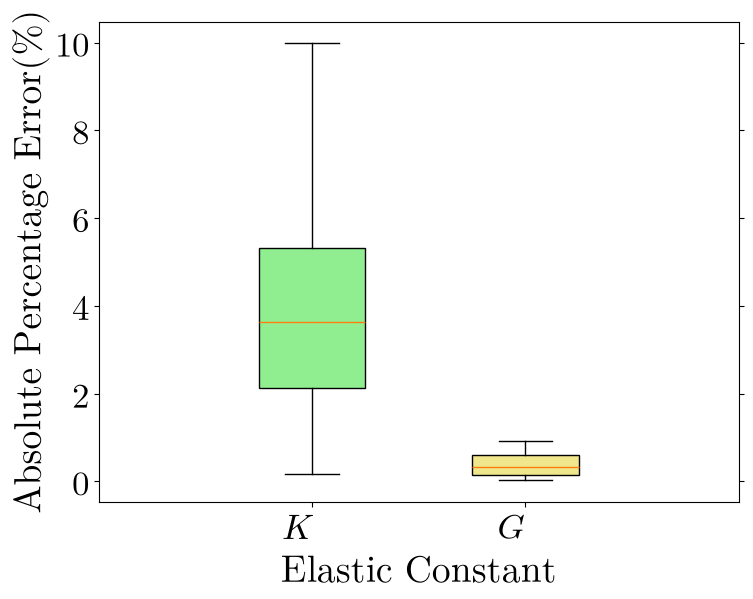

In [21]:
fig_boxKG = plt.figure()
labels_fontsize = 27
keys_reporte = ("K_error", "G_error")
keys_boxplot = (r"$K$", r"$G$")
custom_positions = [1.0, 1.2]
box_width = 0.1
ax2 = fig_boxKG.add_axes([0, 0, 1, 1])
data2 = [datos_iso[key] for key in keys_reporte]
ax2.set_xlim(0.8, 1.4)
ax2.set_xticklabels(keys_boxplot, rotation=45, ha="right") 
ax2.set_xlabel("Elastic Constant", fontsize = labels_fontsize)
ax2.set_ylabel("Absolute Percentage Error(%)", fontsize = labels_fontsize)
ax2.yaxis.set_ticks_position('both') 
medians = [np.median(d) for d in data2]
#ax2.axhline(5, color='red', linestyle='--', linewidth=1.5)
bp2 = ax2.boxplot(data2, showfliers=False, patch_artist=True, positions=custom_positions, widths=box_width)
colors = ['lightgreen', 'khaki', 'lightblue']
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
ax2.tick_params(axis='x', labelsize=25, rotation = "auto")
ax2.tick_params(axis='y', labelsize=25)

plt.savefig("../Thesis_Docs/pictures/fig33_iso.pdf", bbox_inches="tight", pad_inches=0)